# HR Dataset Preprocessing & Dashboard

In [30]:

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import plotly.express as px


In [31]:

# Load Dataset
df = pd.read_csv(r'HR_comma_sep (1).csv')
df.head(20)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


In [32]:
df.tail(20)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
14979,0.09,0.93,6,296,4,0,1,0,technical,medium
14980,0.76,0.89,5,238,5,0,1,0,technical,high
14981,0.73,0.93,5,162,4,0,1,0,technical,low
14982,0.38,0.49,2,137,3,0,1,0,technical,medium
14983,0.72,0.84,5,257,5,0,1,0,technical,medium
14984,0.40,0.56,2,148,3,0,1,0,technical,medium
14985,0.91,0.99,5,254,5,0,1,0,technical,medium
14986,0.85,0.85,4,247,6,0,1,0,technical,low
14987,0.90,0.70,5,206,4,0,1,0,technical,low
14988,0.46,0.55,2,145,3,0,1,0,technical,low


In [33]:

# Basic Info
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.3 MB


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [34]:

# Remove Unnecessary Columns
df.drop(['last_evaluation','Work_accident','promotion_last_5years','left'], axis=1, inplace=True)
df

,satisfaction_level,number_project,average_montly_hours,time_spend_company,Department,salary
0,0.38,2,157,3,sales,low
1,0.80,5,262,6,sales,medium
2,0.11,7,272,4,sales,medium
3,0.72,5,223,5,sales,low
4,0.37,2,159,3,sales,low
...,...,...,...,...,...,...
14994,0.40,2,151,3,support,low
14995,0.37,2,160,3,support,low
14996,0.37,2,143,3,support,low
14997,0.11,6,280,4,support,low


In [35]:
# Duplication check

df.duplicated().sum()

np.int64(3125)

In [39]:
# Remove Duplicates

df = df.drop_duplicates()


In [40]:

# Handle and Check Missing Values
df.isnull().sum()

satisfaction_level      0
number_project          0
average_montly_hours    0
time_spend_company      0
Department              0
salary                  0
dtype: int64

In [41]:
# Encoding Categorical Variables
# One_hot Encoding Applying 
df1 = pd.get_dummies(df, columns=['Department'], drop_first=True)

# Mapping
mapping = {'low': 0, 'medium': 1, 'high': 2}
df['salary_Encoded'] = df['salary'].map(mapping)
df

,satisfaction_level,number_project,average_montly_hours,time_spend_company,Department,salary,salary_Encoded
0,0.38,2,157,3,sales,low,0
1,0.80,5,262,6,sales,medium,1
2,0.11,7,272,4,sales,medium,1
3,0.72,5,223,5,sales,low,0
4,0.37,2,159,3,sales,low,0
...,...,...,...,...,...,...,...
11995,0.90,3,259,10,management,high,2
11996,0.74,5,266,10,management,high,2
11997,0.85,3,185,10,management,high,2
11998,0.33,3,172,10,marketing,high,2


In [42]:
# Feature Scaling
scaler = StandardScaler()
num_cols = ['satisfaction_level','number_project','average_montly_hours','time_spend_company']
df[num_cols] = scaler.fit_transform(df[num_cols])
df

,satisfaction_level,number_project,average_montly_hours,time_spend_company,Department,salary,salary_Encoded
0,-1.044499,-1.562173,-0.895621,-0.274590,sales,low,0
1,0.701109,1.030676,1.262668,1.972984,sales,medium,1
2,-2.166676,2.759242,1.468219,0.474601,sales,medium,1
3,0.368613,1.030676,0.461017,1.223793,sales,low,0
4,-1.086061,-1.562173,-0.854511,-0.274590,sales,low,0
...,...,...,...,...,...,...,...
11995,1.116730,-0.697890,1.201002,4.969750,management,high,2
11996,0.451737,1.030676,1.344888,4.969750,management,high,2
11997,0.908920,-0.697890,-0.320078,4.969750,management,high,2
11998,-1.252310,-0.697890,-0.587294,4.969750,marketing,high,2


In [43]:
# Outlier Detection using IQR
col = ['satisfaction_level','number_project','average_montly_hours','time_spend_company']
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR)))

print("Outliers per column:\n", outliers.sum())

Outliers per column:
 satisfaction_level        0
number_project            0
average_montly_hours      0
time_spend_company      823
dtype: int64


In [44]:
# Remove and Deal with  Outliers
# Apply capping
df[col] = df[col].clip(lower, upper, axis=1)
df

,satisfaction_level,number_project,average_montly_hours,time_spend_company,Department,salary,salary_Encoded
0,-1.044499,-1.562173,-0.895621,-0.274590,sales,low,0
1,0.701109,1.030676,1.262668,1.598388,sales,medium,1
2,-2.166676,2.759242,1.468219,0.474601,sales,medium,1
3,0.368613,1.030676,0.461017,1.223793,sales,low,0
4,-1.086061,-1.562173,-0.854511,-0.274590,sales,low,0
...,...,...,...,...,...,...,...
11995,1.116730,-0.697890,1.201002,1.598388,management,high,2
11996,0.451737,1.030676,1.344888,1.598388,management,high,2
11997,0.908920,-0.697890,-0.320078,1.598388,management,high,2
11998,-1.252310,-0.697890,-0.587294,1.598388,marketing,high,2


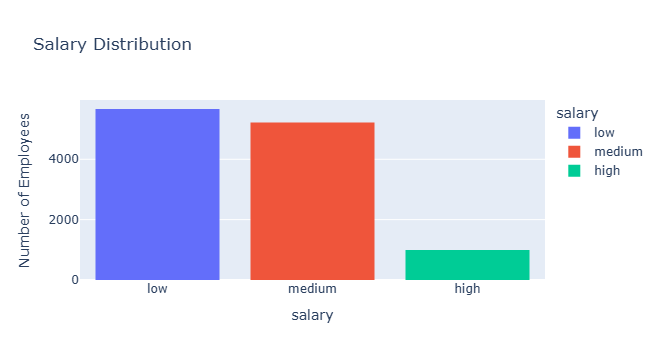

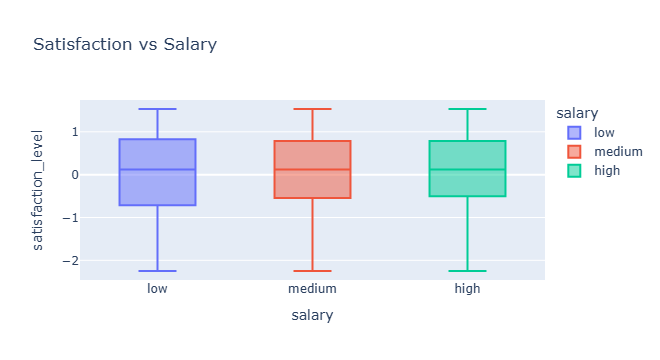

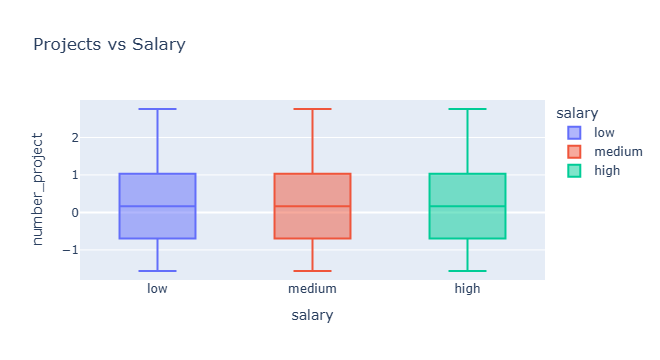

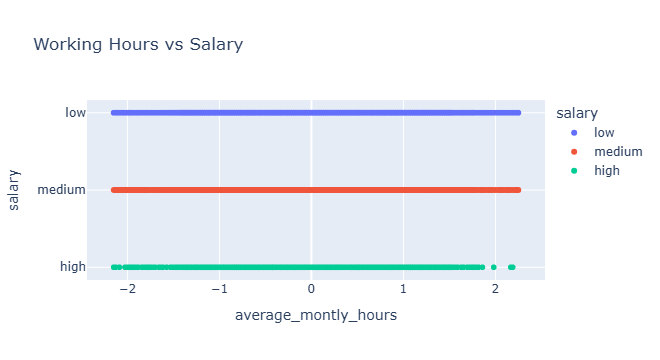

In [45]:
# INTERACTIVE DASHBOARD (Plotly)

# Salary Distribution
fig1 = px.histogram(df,x='salary',title='Salary Distribution',color='salary')
fig1.update_layout( yaxis_title='Number of Employees')
fig1.show()
# Satisfaction vs Salary
fig2 = px.box(df, x='salary', y='satisfaction_level', title='Satisfaction vs Salary',color='salary')
fig2.show()

# Projects vs Salary
fig3 = px.box(df, x='salary', y='number_project', title='Projects vs Salary',color='salary')
fig3.show()

# Working Hours vs Salary
fig4 = px.scatter(df, x='average_montly_hours', y='salary',title='Working Hours vs Salary', color='salary')
fig4.show()
